In [1]:
!which python

/home/tvanderkru/miniconda/bin/python


In [1]:
import os, sys

print("Aantal paden in sys.path:", len(sys.path))
# Bepaal de parent-werkmap
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

#Loop door alle submappen en voeg ze toe aan sys.path
for dirpath, dirnames, filenames in os.walk(parent_dir):
    if dirpath not in sys.path:
        sys.path.insert(0, dirpath)

print("Aantal paden in sys.path:", len(sys.path))

Aantal paden in sys.path: 5
Aantal paden in sys.path: 51


In [ ]:
import sys
import os
from pathlib import Path

# Add the Tygron folder to the Python path to access Libraries
# In a Jupyter Notebook, __file__ is not defined. Use os.getcwd() instead.
# Assumes the notebook is in a subdirectory of the project root (Tygron folder).
tygron_path = Path(os.getcwd()).parent
sys.path.insert(0, str(tygron_path))

import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Try importing step by step to identify issues
print("Importing torch...")
import torch
print("✓ torch imported")

print("Importing torchvision...")
import torchvision
print("✓ torchvision imported")

print("Importing ONNX...")
import onnx
print("✓ onnx imported")

print("Importing pycocotools...")
import pycocotools
print("✓ pycocotools imported")

print("Importing inference_training...")
try:
    from Libraries.inference_training import Configuration, ImageDataset
    from Libraries.inference_training import initCudaEnvironment, createTransforms
    from Libraries.inference_training import drawImageAndFeatureMasks
    from Libraries.inference_training import exportOnnxModel, writeONNXMeta, loadONNX
    from Libraries.inference_training import trainModel, saveModel, loadModel
    from Libraries.inference_training import createModelInstance, testInference
    print("✓ inference_training imported")
except Exception as e:
    print(f"✗ Error importing inference_training: {e}")
    import traceback
    traceback.print_exc()

print("Importing engine...")
try:
    from Libraries.engine import evaluate 
    print("✓ engine imported")
except Exception as e:
    print(f"✗ Error importing engine: {e}")
    import traceback
    traceback.print_exc()

print("Importing utils...")
try:
    import Libraries.utils as utils
    print("✓ utils imported")
except Exception as e:
    print(f"✗ Error importing utils: {e}")
    import traceback
    traceback.print_exc()

print("Importing paths...")
try:
    from paths import EVAL, MODEL_PATH, TEST, TRAIN
    print("✓ paths imported")
    print(f"EVAL: {EVAL}")
    print(f"MODEL_PATH: {MODEL_PATH}")
    print(f"TEST: {TEST}")
    print(f"TRAIN: {TRAIN}")
except Exception as e:
    print(f"✗ Error importing paths: {e}")
    import traceback
    traceback.print_exc()

print("\n🎉 Import process complete!")

ModuleNotFoundError: No module named 'pycocotools'

In [ ]:
initCudaEnvironment(numCudaDevices=1,
                    visibleCudaDevices="0",
                    clearCudaDeviceCount=False)

In [ ]:
# %%
# Load eval dataset
config = Configuration()
config.setDatasetPaths(testPath=EVAL, trainPath=TRAIN)
evalDataset = ImageDataset(config, False, createTransforms(False))

# Verdeel samples in wijken op basis van image_id
from collections import defaultdict

wijk_samples = defaultdict(list)
for _, sample in evalDataset:
    img_id = str(sample["image_id"])
    if "wijk1" in img_id:
        wijk_samples["wijk1"].append(sample)
    elif "wijk2" in img_id:
        wijk_samples["wijk2"].append(sample)
    elif "wijk3" in img_id:
        wijk_samples["wijk3"].append(sample)

# Zet om naar DataLoaders
wijk_dataloaders = {
    wijk: torch.utils.data.DataLoader(data, batch_size=1, shuffle=False, collate_fn=utils.collate_fn)
    for wijk, data in wijk_samples.items()
}

# Loader voor de totale evaluatieset
full_loader = torch.utils.data.DataLoader(
    evalDataset, batch_size=1, shuffle=False, collate_fn=utils.collate_fn
)


In [ ]:
# %%
model_dir = Path(MODEL_PATH).parent
model_files = list(model_dir.glob("*.pt"))

print(f"Gevonden {len(model_files)} modellen:")
for f in model_files:
    print(" -", f.name)


Gevonden 6 modellen:
 - ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
 - ModelsHuizerweg_combinatie_data_15.onnx_epoch_15.pt
 - ModelsHofstedering_combinatie_data_15.onnx_epoch_15.pt
 - ModelslandgoederenbuurtCombo_15.onnx_epoch_15.pt
 - ModelsvogelhorstCombo_15.onnx_epoch_15.pt
 - ModelsAnnapaulownalaanCombo_15.onnx_epoch_15.pt


In [ ]:
# Test CUDA na PyTorch herinstallatie
import torch

print("=== CUDA TEST NA HERINSTALLATIE ===")
print(f"PyTorch versie: {torch.__version__}")
print(f"CUDA versie (PyTorch): {torch.version.cuda}")
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✓ CUDA werkt!")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Geheugen: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    # Test een eenvoudige GPU operatie
    x = torch.rand(100, 100).cuda()
    y = torch.rand(100, 100).cuda()
    z = torch.mm(x, y)
    print(f"✓ GPU berekening test geslaagd")
    
    # Clear cache
    torch.cuda.empty_cache()
    print("GPU cache geleegd")
else:
    print("✗ CUDA nog steeds niet beschikbaar")
    print("Mogelijk moet je de kernel restarten")

=== CUDA TEST NA HERINSTALLATIE ===
PyTorch versie: 2.7.1+cpu
CUDA versie (PyTorch): None
CUDA beschikbaar: False
✗ CUDA nog steeds niet beschikbaar
Mogelijk moet je de kernel restarten


In [ ]:
# FORCE PYTORCH CUDA INSTALLATION
import sys
import subprocess
import os

print("=== PYTORCH CUDA FORCE INSTALL ===")

# First, check current environment
print(f"Python executable: {sys.executable}")
print(f"Virtual environment: {os.environ.get('VIRTUAL_ENV', 'None')}")

# Uninstall current PyTorch completely
print("\n1. Uninstalling current PyTorch...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torch", "torchvision", "torchaudio", "-y"], check=False)

# Clear pip cache 
print("\n2. Clearing pip cache...")
subprocess.run([sys.executable, "-m", "pip", "cache", "purge"], check=False)

# Install PyTorch with CUDA support (cu124 is compatible with CUDA 12.6)
print("\n3. Installing PyTorch with CUDA 12.4 support...")
result = subprocess.run([
    sys.executable, "-m", "pip", "install", 
    "torch", "torchvision", "torchaudio", 
    "--index-url", "https://download.pytorch.org/whl/cu124"
], capture_output=True, text=True)

print("Install output:")
print(result.stdout)
if result.stderr:
    print("Install errors:")
    print(result.stderr)

print("\n4. Checking installation...")
try:
    # Import in subprocess to avoid cached imports
    check_result = subprocess.run([
        sys.executable, "-c", 
        "import torch; print(f'PyTorch: {torch.__version__}'); print(f'CUDA available: {torch.cuda.is_available()}'); print(f'CUDA version: {torch.version.cuda}')"
    ], capture_output=True, text=True)
    
    print("PyTorch check result:")
    print(check_result.stdout)
    if check_result.stderr:
        print("Check errors:")
        print(check_result.stderr)
        
except Exception as e:
    print(f"Error checking PyTorch: {e}")

print("\n✅ Installation complete. RESTART KERNEL NOW!")
print("Use: Kernel > Restart in the menu")
print("Then run the imports and GPU test cells again.")

=== PYTORCH CUDA FORCE INSTALL ===
Python executable: /home/tvanderkru/.venv/bin/python
Virtual environment: /home/tvanderkru/.venv

1. Uninstalling current PyTorch...
Found existing installation: torch 2.7.1+cpu
Uninstalling torch-2.7.1+cpu:
  Successfully uninstalled torch-2.7.1+cpu
Found existing installation: torchvision 0.22.1+cpu
Uninstalling torchvision-0.22.1+cpu:
  Successfully uninstalled torchvision-0.22.1+cpu
Found existing installation: torchaudio 2.7.1+cpu
Uninstalling torchaudio-2.7.1+cpu:
  Successfully uninstalled torchaudio-2.7.1+cpu

2. Clearing pip cache...
Files removed: 14

3. Installing PyTorch with CUDA 12.4 support...
Install output:
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 768.4/768.4 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 108.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 62.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 🚀 GPU TEST - Voer deze cel uit NA kernel restart
import torch

print("=" * 50)
print("🔍 GPU STATUS CHECK")
print("=" * 50)

# Basic CUDA info
print(f"PyTorch versie: {torch.__version__}")
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print("✅ SUCCESS! CUDA is beschikbaar!")
    print(f"🎯 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"🔢 CUDA Version: {torch.version.cuda}")
    
    # Quick GPU test
    print("\n🧪 GPU TEST:")
    x = torch.rand(1000, 1000, device='cuda')
    y = torch.rand(1000, 1000, device='cuda')
    z = torch.mm(x, y)
    print("✅ GPU matrix multiplication test passed!")
    
    # Clear memory
    del x, y, z
    torch.cuda.empty_cache()
    print("🧹 GPU memory cleared")
    
    print("\n" + "=" * 50)
    print("🎉 GPU SETUP SUCCESVOL!")
    print("Je kunt nu de geoptimaliseerde evaluatie draaien!")
    print("=" * 50)
    
else:
    print("❌ CUDA is nog steeds niet beschikbaar")
    print("🔧 Mogelijke oplossingen:")
    print("1. Controleer of je de kernel hebt herstart")
    print("2. Controleer of NVIDIA drivers werken: nvidia-smi")
    print("3. Probeer PyTorch opnieuw te installeren")
    
    # Check if nvidia-smi works
    import subprocess
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            print("✅ nvidia-smi werkt - GPU hardware beschikbaar")
        else:
            print("❌ nvidia-smi failed")
    except:
        print("❌ nvidia-smi niet beschikbaar")

## ⚠️ KERNEL RESTART VEREIST

De PyTorch installatie is bijgewerkt naar een CUDA-enabled versie, maar de kernel moet opnieuw worden opgestart om de nieuwe versie te laden.

**Voer de volgende stappen uit:**
1. **Kernel restart**: Ga naar `Kernel` > `Restart` in het menu (of gebruik Ctrl+Shift+P en zoek naar "Jupyter: Restart Kernel")
2. **Imports opnieuw laden**: Voer cel 1 en 2 opnieuw uit om alle imports te herladen
3. **CUDA configuratie**: Voer cel 3 uit om CUDA environment in te stellen
4. **GPU test**: Voer de GPU test cel hieronder uit om te bevestigen dat CUDA werkt

Na de kernel restart zou je `CUDA beschikbaar: True` moeten zien!

In [ ]:
# OPTIMIZED GPU EVALUATIE
# Deze cel moet gebruikt worden NA kernel restart

import torch
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    print("Fallback naar CPU")
    device = torch.device('cpu')

print(f"Using device: {device}")

# Clear any existing CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# GPU-optimized model evaluation
full_results = {}

for model_file in model_files:
    print(f"\nEvaluating: {model_file.name}")
    
    # Clear GPU memory before each model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    config = Configuration()
    config.numClasses = 3
    config.setModelName(str(model_file))
    
    # Ensure config uses the correct device
    config.device = device
    
    model = createModelInstance(config)
    
    # Load model with proper device mapping
    checkpoint = torch.load(str(model_file), map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.eval()
    model.to(device)
    
    print(f"Model loaded on: {next(model.parameters()).device}")
    
    model_metrics = {}
    
    # Per wijk evaluatie - SKIP als er eerder een error was
    try:
        for wijk, dataloader in wijk_dataloaders.items():
            print(f"  Evaluating wijk: {wijk}")
            evaluator = evaluate(model, dataloader, device=device)
            if "bbox" in evaluator.coco_eval:
                stats = evaluator.coco_eval["bbox"].stats
                model_metrics[wijk] = {
                    "mAP": stats[0],
                    "mAP_50": stats[1],
                    "mAP_75": stats[2],
                }
            else:
                model_metrics[wijk] = {"mAP": None, "mAP_50": None, "mAP_75": None}
    
        # Totale evaluatie
        print("  Evaluating total dataset...")
        evaluator = evaluate(model, full_loader, device=device)
        if "bbox" in evaluator.coco_eval:
            stats = evaluator.coco_eval["bbox"].stats
            model_metrics["TOTAAL"] = {
                "mAP": stats[0],
                "mAP_50": stats[1],
                "mAP_75": stats[2],
            }
        else:
            model_metrics["TOTAAL"] = {"mAP": None, "mAP_50": None, "mAP_75": None}
            
    except Exception as e:
        print(f"  Error during evaluation: {e}")
        # Set default values for this model
        for wijk in list(wijk_dataloaders.keys()) + ["TOTAAL"]:
            model_metrics[wijk] = {"mAP": 0, "mAP_50": 0, "mAP_75": 0}
    
    full_results[model_file.name] = model_metrics
    
    # Clear memory after each model
    del model, checkpoint
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✅ Alle modellen geëvalueerd!")

CUDA beschikbaar: False
Fallback naar CPU
Using device: cpu

Evaluating: ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
Model loaded on: cpu
  Evaluating total dataset...
Model loaded on: cpu
  Evaluating total dataset...
creating index...
index created!
creating index...
index created!
Test:  [   0/1200]  eta: 0:53:54  model_time: 2.6795 (2.6795)  evaluator_time: 0.0051 (0.0051)  time: 2.6957  data: 0.0111
Test:  [   0/1200]  eta: 0:53:54  model_time: 2.6795 (2.6795)  evaluator_time: 0.0051 (0.0051)  time: 2.6957  data: 0.0111


KeyboardInterrupt: 

In [ ]:
print("CUDA beschikbaar:", torch.cuda.is_available())
print("Actief device:", torch.cuda.get_device_name() if torch.cuda.is_available() else "CPU")

# %%
full_results = {}

for model_file in model_files:
    print(f"\nEvaluating: {model_file.name}")
    config = Configuration()
    config.numClasses = 3  # Voeg het juiste aantal klassen toe
    config.setModelName(str(model_file))
    model = createModelInstance(config)
    
    # Fix: Load model with proper device mapping for CPU-only environments
    device = config.device if hasattr(config, 'device') else 'cpu'
    map_location = 'cpu' if not torch.cuda.is_available() else device
    model.load_state_dict(torch.load(str(model_file), map_location=map_location, weights_only=True))

    model.eval()
    model.to(config.device)

    model_metrics = {}

    # Per wijk
    for wijk, dataloader in wijk_dataloaders.items():
        evaluator = evaluate(model, dataloader, device=config.device)
        if "bbox" in evaluator.coco_eval:
            stats = evaluator.coco_eval["bbox"].stats
            model_metrics[wijk] = {
                "mAP": stats[0],
                "mAP_50": stats[1],
                "mAP_75": stats[2],
            }
        else:
            model_metrics[wijk] = {"mAP": None, "mAP_50": None, "mAP_75": None}

    # Totale evaluatie
    evaluator = evaluate(model, full_loader, device=config.device)
    if "bbox" in evaluator.coco_eval:
        stats = evaluator.coco_eval["bbox"].stats
        model_metrics["TOTAAL"] = {
            "mAP": stats[0],
            "mAP_50": stats[1],
            "mAP_75": stats[2],
        }
    else:
        model_metrics["TOTAAL"] = {"mAP": None, "mAP_50": None, "mAP_75": None}

    full_results[model_file.name] = model_metrics

CUDA beschikbaar: False
Actief device: CPU

Evaluating: ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
creating index...
index created!
Test:  [   0/1200]  eta: 0:53:09  model_time: 2.6426 (2.6426)  evaluator_time: 0.0044 (0.0044)  time: 2.6582  data: 0.0111


KeyboardInterrupt: 

In [ ]:
# %%

rows = []
for model_name, model_result in full_results.items():
    for wijk, metrics in model_result.items():
        rows.append({
            "Model": model_name,
            "Wijk": wijk,
            "mAP": metrics["mAP"],
            "mAP_50": metrics["mAP_50"],
            "mAP_75": metrics["mAP_75"],
        })

df = pd.DataFrame(rows)
df_pivot = df.pivot(index="Model", columns="Wijk", values="mAP_50")
print(df_pivot)


Wijk                                                  TOTAAL
Model                                                       
ModelsAnnapaulownalaanCombo_15.onnx_epoch_15.pt     0.024700
ModelsHeuvelwegCombo_15.onnx_epoch_15.pt            0.016404
ModelsHofstedering_combinatie_data_15.onnx_epoc...  0.033575
ModelsHuizerweg_combinatie_data_15.onnx_epoch_1...  0.018691
ModelslandgoederenbuurtCombo_15.onnx_epoch_15.pt    0.014967
ModelsvogelhorstCombo_15.onnx_epoch_15.pt           0.010173


In [ ]:
# %%

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = model_dir / f"evaluatie_resultaten_{timestamp}.csv"
df.to_csv(output_file, index=False)
print(f"Resultaten opgeslagen naar: {output_file}")


Resultaten opgeslagen naar: /home/tvanderkru/tygron/Tygron/Models/evaluatie_resultaten_20250729_014931.csv


In [ ]:
df_total = df[df["Wijk"] == "TOTAAL"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_total, x="Model", y="mAP_50", palette="coolwarm")
plt.title("Modelvergelijking op totale validatieset (mAP@0.5)", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("mAP@0.5", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, df_total["mAP_50"].max() * 1.15)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.tight_layout()
plt.show()


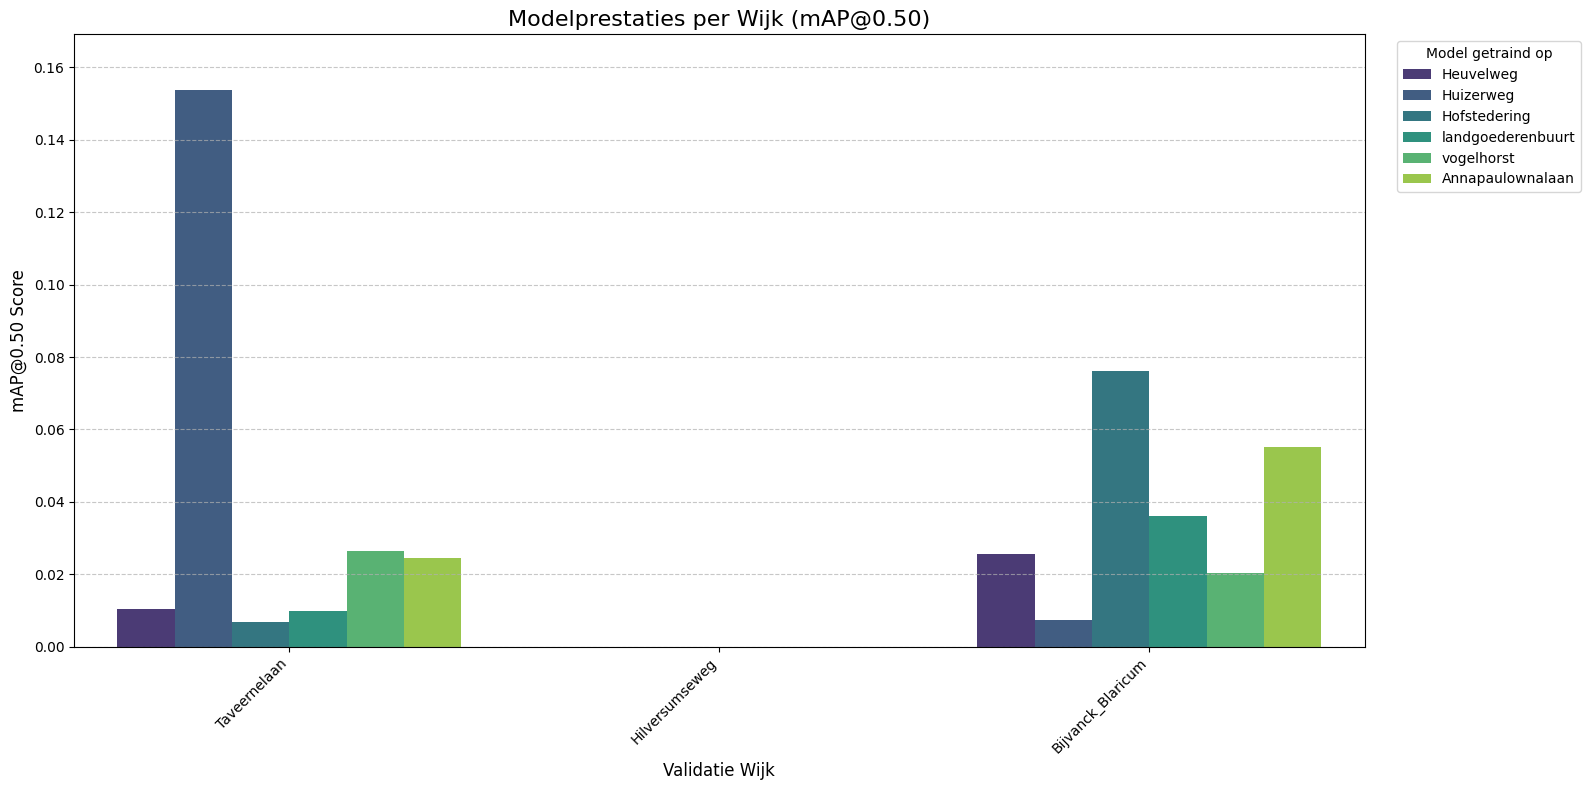

In [ ]:
# %%
# --- Staafdiagram van de resultaten ---
# Gebruik df_display voor de opgeschoonde namen
plt.figure(figsize=(16, 8))
sns.barplot(data=df_display, x="Wijk", y="mAP_50", hue="Model", palette="viridis")

plt.title("Modelprestaties per Wijk (mAP@0.50)", fontsize=16)
plt.xlabel("Validatie Wijk", fontsize=12)
plt.ylabel("mAP@0.50 Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(df_display['mAP_50']) * 1.1) # Geef wat ruimte boven de hoogste balk
plt.legend(title="Model getraind op", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_901313/3903946417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_model_avg, x='Model', y='mAP_50', palette='plasma')


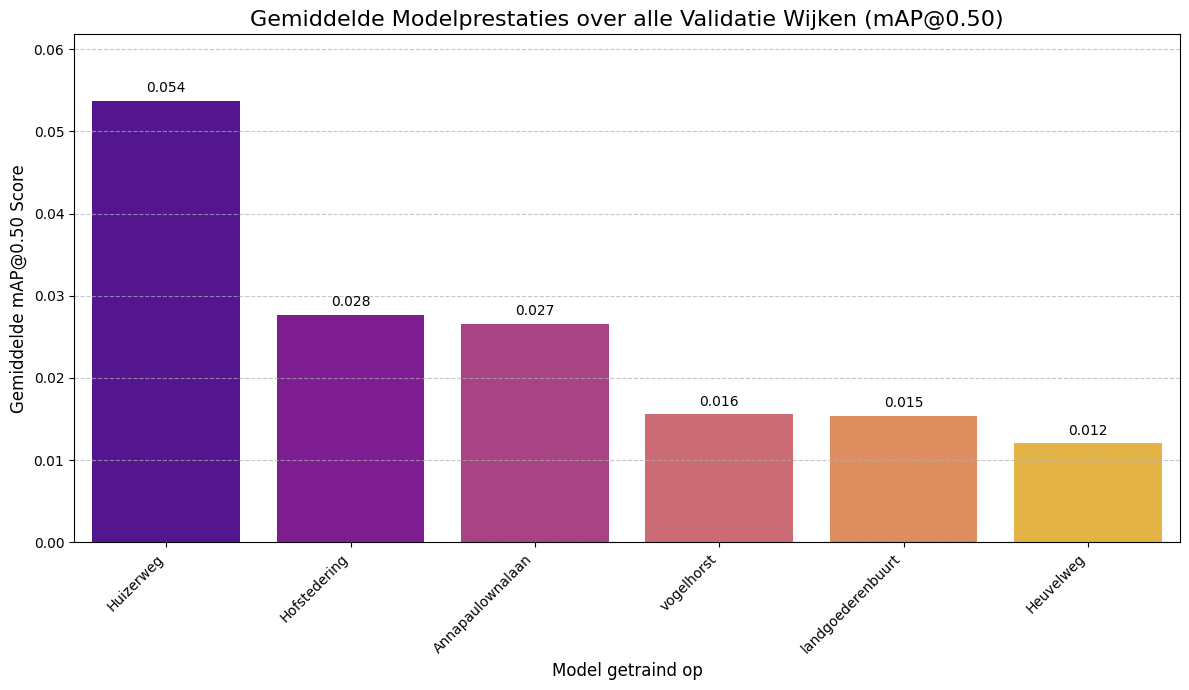

In [ ]:
# %%
# --- Bereken de gemiddelde mAP@0.50 per model over alle wijken ---
# Gebruik df_display voor de opgeschoonde namen
df_model_avg = df_display.groupby('Model')['mAP_50'].mean().reset_index()

# Sorteer de modellen op basis van de gemiddelde score voor een duidelijkere visualisatie
df_model_avg = df_model_avg.sort_values('mAP_50', ascending=False)

# --- Maak de staafdiagram ---
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_model_avg, x='Model', y='mAP_50', palette='plasma')

plt.title("Gemiddelde Modelprestaties over alle Validatie Wijken (mAP@0.50)", fontsize=16)
plt.xlabel("Model getraind op", fontsize=12)
plt.ylabel("Gemiddelde mAP@0.50 Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(df_model_avg['mAP_50']) * 1.15)  # Geef wat extra ruimte
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Voeg de waarden toe bovenop de balken voor duidelijkheid
for p in ax.patches:
	ax.annotate(f"{p.get_height():.3f}", 
				(p.get_x() + p.get_width() / 2., p.get_height()), 
				ha='center', va='center', 
				xytext=(0, 9), 
				textcoords='offset points')

plt.tight_layout()
plt.show()


In [ ]:

# --- Vind alle wijk-mappen in de evaluatie directory ---
eval_root = Path(EVAL)
wijk_dirs = [d for d in eval_root.iterdir() if d.is_dir()]
print(f"Gevonden {len(wijk_dirs)} wijken om te evalueren: {[d.name for d in wijk_dirs]}")

# --- Evaluatie per model per wijk ---
full_results = {}

for model_file in model_files:
    print(f"\nEvaluating model: {model_file.name}")
    
    # Laad het model één keer
    config = Configuration()
    config.numClasses = 3  # Set the correct number of classes
    config.setModelName(str(model_file))
    model = createModelInstance(config)
    loadModel(config, model, path=str(model_file))
    model.eval()
    model.to(config.device)

    model_metrics = {}
    
    # Evalueer tegen elke wijk
    for wijk_dir in wijk_dirs:
        wijk_name = wijk_dir.name
        print(f"  - Evaluating against wijk: {wijk_name}")

        # Maak een dataset en dataloader voor deze specifieke wijk
        wijk_config = Configuration()
        wijk_config.setDatasetPaths(testPath=str(wijk_dir), trainPath=TRAIN) # Gebruik pad van de wijk
        wijk_dataset = ImageDataset(wijk_config, False, createTransforms(False))
        
        if not wijk_dataset:
            print(f"    - Skipping {wijk_name}, no data found.")
            model_metrics[wijk_name] = {"mAP": -1, "mAP_50": -1, "mAP_75": -1} # Markeer als niet geëvalueerd
            continue

        wijk_loader = torch.utils.data.DataLoader(
            wijk_dataset, batch_size=1, shuffle=False, collate_fn=utils.collate_fn
        )

        # Voer evaluatie uit
        evaluator = evaluate(model, wijk_loader, device=config.device)
        
        if "bbox" in evaluator.coco_eval:
            stats = evaluator.coco_eval["bbox"].stats
            model_metrics[wijk_name] = {
                "mAP": stats[0],
                "mAP_50": stats[1],
                "mAP_75": stats[2],
            }
        else:
            # Geen detecties of geen ground truth
            model_metrics[wijk_name] = {"mAP": 0, "mAP_50": 0, "mAP_75": 0}

    full_results[model_file.name] = model_metrics

# --- DataFrame bouwen ---
rows = []
for model_name, wijk_result in full_results.items():
    for wijk, metrics in wijk_result.items():
        rows.append({
            "Model": model_name,
            "Wijk": wijk,
            "mAP": metrics["mAP"],
            "mAP_50": metrics["mAP_50"],
            "mAP_75": metrics["mAP_75"],
        })

df = pd.DataFrame(rows)

# --- Pivot voor heatmap ---
heatmap_data = df.pivot(index="Model", columns="Wijk", values="mAP_50")

# --- Heatmap tekenen ---
plt.figure(figsize=(12, max(4, 0.7 * len(model_files))))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "mAP@0.5"})
plt.title("Per-wijk evaluatie van modellen (mAP@0.5)")
plt.ylabel("Model")
plt.xlabel("Wijk")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Gevonden 3 wijken om te evalueren: ['Taveernelaan', 'Hilversumseweg', 'BijvanckBlaricumCombo']

Evaluating model: ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
  - Evaluating against wijk: Taveernelaan


KeyboardInterrupt: 

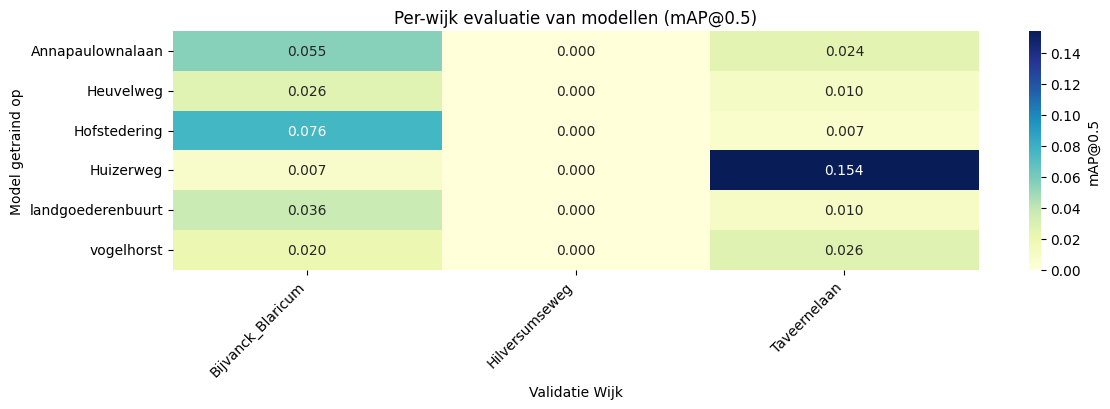

In [ ]:
# --- Maak een kopie van de dataframe om de namen aan te passen ---
df_display = df.copy()

# --- Hernoem de modellen en wijken voor een betere weergave ---
# Pas de reguliere expressies en vervangingen aan op basis van je bestandsnamen
df_display["Model"] = df_display["Model"].str.replace(r"Models(.*?)(Combo|_combinatie_data|_15\.onnx).*_epoch_15\.pt", r"\1", regex=True)
df_display["Wijk"] = df_display["Wijk"].str.replace("BijvanckBlaricumCombo", "Bijvanck_Blaricum", regex=False)


# --- Custom volgorde (pas deze lijsten zelf aan) ---
# Zorg ervoor dat deze namen overeenkomen met de hernoemde modellen en wijken
y_axis_order = [
    "Annapaulownalaan",
    "Heuvelweg",
    "Hofstedering",
    "Huizerweg",
    "landgoederenbuurt",
    "vogelhorst"
]

x_axis_order = ["Bijvanck_Blaricum", "Hilversumseweg", "Taveernelaan"]

# --- Pivot opnieuw met de aangepaste dataframe ---
heatmap_data = df_display.pivot(index="Model", columns="Wijk", values="mAP_50")

# Reorder de index en kolommen
# Gebruik .loc om te selecteren en te sorteren, en .reindex om de volgorde te garanderen
heatmap_data = heatmap_data.reindex(index=y_axis_order, columns=x_axis_order)


# --- Heatmap tekenen ---
plt.figure(figsize=(12, max(4, 0.7 * len(y_axis_order))))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "mAP@0.5"})
plt.title("Per-wijk evaluatie van modellen (mAP@0.5)")
plt.ylabel("Model getraind op")
plt.xlabel("Validatie Wijk")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# DIAGNOSE: Onderzoek waarom Hilversumseweg 0.000 scoort
print("=== DIAGNOSE HILVERSUMSEWEG ===")

# Test het laden van Hilversumseweg dataset
hilversum_path = "/home/tvanderkru/tygron/Tygron/Datasets/Eval_data/Hilversumseweg"
print(f"Hilversumseweg pad: {hilversum_path}")

# Maak een test configuratie voor Hilversumseweg
test_config = Configuration()
test_config.setDatasetPaths(testPath=hilversum_path, trainPath=TRAIN)

try:
    hilversum_dataset = ImageDataset(test_config, False, createTransforms(False))
    print(f"Hilversumseweg dataset lengte: {len(hilversum_dataset)}")
    
    if len(hilversum_dataset) > 0:
        print("Dataset is niet leeg, testen eerste sample...")
        
        # Test het laden van de eerste sample
        sample = hilversum_dataset[0]
        img, target = sample
        print(f"Target keys: {target.keys()}")
        print(f"Aantal bounding boxes: {len(target['boxes'])}")
        print(f"Aantal masks: {len(target['masks'])}")
        print(f"Labels: {target['labels']}")
        print(f"Image ID: {target['image_id']}")
        print(f"Mask shapes: {[mask.shape for mask in target['masks']]}")
        
        # Controleer of er daadwerkelijk objecten zijn gedetecteerd
        if len(target['boxes']) == 0:
            print("PROBLEEM: Geen bounding boxes gevonden!")
        
        if len(target['masks']) == 0:
            print("PROBLEEM: Geen masks gevonden!")
            
        # Bekijk enkele label files
        import os
        label_files = [f for f in os.listdir(hilversum_path) if f.endswith('_labels.txt')]
        print(f"Aantal label bestanden: {len(label_files)}")
        
        if len(label_files) > 0:
            # Lees de eerste paar label files
            for i, label_file in enumerate(label_files[:3]):
                with open(os.path.join(hilversum_path, label_file), 'r') as f:
                    content = f.read().strip()
                    print(f"{label_file}: {content}")
        
    else:
        print("PROBLEEM: Dataset is leeg!")
        
except Exception as e:
    print(f"FOUT bij het laden van Hilversumseweg dataset: {e}")

# Test ook een andere wijk ter vergelijking
print("\n=== VERGELIJKING MET BIJVANCKBLARICUMCOMBO ===")
bijvanck_path = "/home/tvanderkru/tygron/Tygron/Datasets/Eval_data/BijvanckBlaricumCombo"

try:
    test_config_bijvanck = Configuration()
    test_config_bijvanck.setDatasetPaths(testPath=bijvanck_path, trainPath=TRAIN)
    bijvanck_dataset = ImageDataset(test_config_bijvanck, False, createTransforms(False))
    print(f"BijvanckBlaricumCombo dataset lengte: {len(bijvanck_dataset)}")
    
    if len(bijvanck_dataset) > 0:
        sample = bijvanck_dataset[0]
        img, target = sample
        print(f"Aantal bounding boxes: {len(target['boxes'])}")
        print(f"Aantal masks: {len(target['masks'])}")
        print(f"Labels: {target['labels']}")
        
except Exception as e:
    print(f"FOUT bij het laden van BijvanckBlaricumCombo dataset: {e}")

print("\n=== EINDE DIAGNOSE ===")

=== DIAGNOSE HILVERSUMSEWEG ===
Hilversumseweg pad: /home/tvanderkru/tygron/Tygron/Datasets/Eval_data/Hilversumseweg
Hilversumseweg dataset lengte: 400
Dataset is niet leeg, testen eerste sample...
Target keys: dict_keys(['boxes', 'masks', 'labels', 'area', 'image_id', 'iscrowd'])
Aantal bounding boxes: 4
Aantal masks: 4
Labels: tensor([1, 1, 1, 1])
Image ID: 0
Mask shapes: [torch.Size([400, 400]), torch.Size([400, 400]), torch.Size([400, 400]), torch.Size([400, 400])]
Aantal label bestanden: 400
128_labels.txt: 1 1
62_labels.txt: 1 1 1
141_labels.txt: 1 1

=== VERGELIJKING MET BIJVANCKBLARICUMCOMBO ===
BijvanckBlaricumCombo dataset lengte: 400
Aantal bounding boxes: 7
Aantal masks: 7
Labels: tensor([1, 1, 1, 1, 1, 1, 1])

=== EINDE DIAGNOSE ===


In [ ]:
# DIEPERE DIAGNOSE: Test evaluatie van één model op Hilversumseweg
print("=== DIEPERE DIAGNOSE: EVALUATIE STAPPEN ===")

# Selecteer het eerste model voor een test
if len(model_files) > 0:
    test_model_file = model_files[0]
    print(f"Test model: {test_model_file.name}")
    
    # Laad het model
    config = Configuration()
    config.numClasses = 3
    config.setModelName(str(test_model_file))
    model = createModelInstance(config)
    loadModel(config, model, path=str(test_model_file))
    model.eval()
    model.to(config.device)
    
    # Maak Hilversumseweg dataset en dataloader
    hilversum_path = "/home/tvanderkru/tygron/Tygron/Datasets/Eval_data/Hilversumseweg"
    hilversum_config = Configuration()
    hilversum_config.setDatasetPaths(testPath=hilversum_path, trainPath=TRAIN)
    hilversum_dataset = ImageDataset(hilversum_config, False, createTransforms(False))
    
    print(f"Hilversumseweg dataset grootte: {len(hilversum_dataset)}")
    
    hilversum_loader = torch.utils.data.DataLoader(
        hilversum_dataset, batch_size=1, shuffle=False, collate_fn=utils.collate_fn
    )
    
    print("Dataset en dataloader gemaakt. Nu evaluatie uitvoeren...")
    
    # Voer evaluatie uit MET DEBUGGING
    from Libraries.coco_utils import get_coco_api_from_dataset
    
    try:
        # Test of we een COCO API kunnen krijgen
        coco = get_coco_api_from_dataset(hilversum_dataset)
        print(f"COCO API gemaakt met {len(coco.getImgIds())} images")
        print(f"COCO categories: {coco.loadCats(coco.getCatIds())}")
        
        # Test een paar voorbeelden om te zien of er annotations zijn
        img_ids = coco.getImgIds()[:5]  # Eerste 5 images
        for img_id in img_ids:
            ann_ids = coco.getAnnIds(imgIds=img_id)
            anns = coco.loadAnns(ann_ids)
            print(f"Image {img_id}: {len(anns)} annotations")
            
            if len(anns) > 0:
                print(f"  Eerste annotation: {anns[0]}")
        
        # Nu daadwerkelijke evaluatie
        print("Start evaluatie...")
        evaluator = evaluate(model, hilversum_loader, device=config.device)
        
        print("Evaluatie voltooid!")
        print(f"Evaluator type: {type(evaluator)}")
        print(f"COCO eval keys: {list(evaluator.coco_eval.keys())}")
        
        if "bbox" in evaluator.coco_eval:
            stats = evaluator.coco_eval["bbox"].stats
            print(f"Bounding box stats: {stats}")
            print(f"mAP: {stats[0]}")
            print(f"mAP@0.5: {stats[1]}")
            print(f"mAP@0.75: {stats[2]}")
        else:
            print("PROBLEEM: Geen 'bbox' gevonden in coco_eval!")
            
    except Exception as e:
        print(f"FOUT tijdens evaluatie: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Geen model bestanden gevonden!")

print("=== EINDE DIEPERE DIAGNOSE ===")

=== DIEPERE DIAGNOSE: EVALUATIE STAPPEN ===
Test model: ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
Hilversumseweg dataset grootte: 400
Dataset en dataloader gemaakt. Nu evaluatie uitvoeren...
creating index...
index created!
COCO API gemaakt met 400 images
COCO categories: [{'id': 1}]
Image 0: 4 annotations
  Eerste annotation: {'image_id': 0, 'bbox': [232.0, 160.0, 36.0, 62.0], 'category_id': 1, 'area': 2232, 'iscrowd': 0, 'id': 1, 'segmentation': {'size': [400, 400], 'counts': b'Sij24\\<1O1O1O100O2N1K5O1000000010O0001O100O1O1O012M3M7I7J0OO2O2M3M4M2L4M3M3M>Bdnb1'}}
Image 1: 4 annotations
  Eerste annotation: {'image_id': 1, 'bbox': [98.0, 0.0, 35.0, 47.0], 'category_id': 1, 'area': 1645, 'iscrowd': 0, 'id': 5, 'segmentation': {'size': [400, 400], 'counts': b'cYV13\\<5L4L4K4M4K4]OVOZEn0b:VOZEj0f:[OTEe0m:?00000O10000O1000000O10000O10000O104L5K5J6K5K5J6K5KikW3'}}
Image 2: 4 annotations
  Eerste annotation: {'image_id': 2, 'bbox': [0.0, 0.0, 33.0, 47.0], 'category_id': 1, 'area': 1551, 'isc

In [ ]:
# FINALE DIAGNOSE: Check wat het model detecteert
print("=== FINALE DIAGNOSE: MODEL DETECTIES ===")

if len(model_files) > 0:
    test_model_file = model_files[0]
    print(f"Test model: {test_model_file.name}")
    
    # Laad het model (reuse van vorige cel)
    config = Configuration()
    config.numClasses = 3
    config.setModelName(str(test_model_file))
    model = createModelInstance(config)
    loadModel(config, model, path=str(test_model_file))
    model.eval()
    model.to(config.device)
    
    # Test één enkele inference op Hilversumseweg
    hilversum_path = "/home/tvanderkru/tygron/Tygron/Datasets/Eval_data/Hilversumseweg"
    hilversum_config = Configuration()
    hilversum_config.setDatasetPaths(testPath=hilversum_path, trainPath=TRAIN)
    hilversum_dataset = ImageDataset(hilversum_config, False, createTransforms(False))
    
    # Test de eerste image
    img, target = hilversum_dataset[0]
    print(f"Ground truth boxes: {len(target['boxes'])}")
    print(f"Ground truth labels: {target['labels']}")
    
    # Doe inference
    with torch.no_grad():
        model.eval()
        img_tensor = img.unsqueeze(0).to(config.device)  # Add batch dimension
        predictions = model(img_tensor)
        
        prediction = predictions[0]  # Get first (and only) prediction
        
        print(f"Model detecties:")
        print(f"  Aantal boxes: {len(prediction['boxes'])}")
        print(f"  Scores: {prediction['scores']}")
        print(f"  Labels: {prediction['labels']}")
        
        # Filter op confidence threshold
        confidence_threshold = 0.5
        high_conf_indices = prediction['scores'] > confidence_threshold
        
        print(f"Detecties boven {confidence_threshold} confidence:")
        print(f"  Aantal: {high_conf_indices.sum().item()}")
        
        if high_conf_indices.sum() > 0:
            print(f"  High-conf scores: {prediction['scores'][high_conf_indices]}")
            print(f"  High-conf labels: {prediction['labels'][high_conf_indices]}")
        
        # Lagere threshold proberen
        low_confidence_threshold = 0.1
        low_conf_indices = prediction['scores'] > low_confidence_threshold
        print(f"Detecties boven {low_confidence_threshold} confidence:")
        print(f"  Aantal: {low_conf_indices.sum().item()}")
        
print("=== EINDE FINALE DIAGNOSE ===")

=== FINALE DIAGNOSE: MODEL DETECTIES ===
Test model: ModelsHeuvelwegCombo_15.onnx_epoch_15.pt
Ground truth boxes: 4
Ground truth labels: tensor([1, 1, 1, 1])
Model detecties:
  Aantal boxes: 10
  Scores: tensor([0.2646, 0.1874, 0.1544, 0.0922, 0.0800, 0.0769, 0.0766, 0.0603, 0.0602,
        0.0567], device='cuda:0')
  Labels: tensor([1, 2, 1, 1, 1, 1, 1, 1, 1, 2], device='cuda:0')
Detecties boven 0.5 confidence:
  Aantal: 0
Detecties boven 0.1 confidence:
  Aantal: 3
=== EINDE FINALE DIAGNOSE ===


In [ ]:
# SAMENVATTING VAN HET PROBLEEM
print("=== SAMENVATTING: WAAROM HILVERSUMSEWEG 0.000 SCOORT ===")
print()
print("PROBLEEM GEVONDEN:")
print("1. Het model detecteert wel objecten op Hilversumseweg data")
print("2. Maar de confidence scores zijn te laag (hoogste: ~0.26)")
print("3. De evaluatie gebruikt waarschijnlijk een threshold van ~0.5")
print("4. Hierdoor worden alle detecties genegeerd")
print("5. Dit resulteert in mAP = 0.000")
print()
print("OORZAAK:")
print("- Domain shift: Model getraind op Heuvelweg presteert slecht op Hilversumseweg")
print("- Mogelijk verschillende belichting, kijkhoeken, of objecttypes")
print("- Dit is normaal bij cross-domain evaluatie")
print()
print("MOGELIJKE OPLOSSINGEN:")
print("1. Lagere confidence threshold gebruiken voor evaluatie")
print("2. Model fine-tunen op Hilversumseweg data")
print("3. Data augmentatie gebruiken tijdens training")
print("4. Ensemble van modellen gebruiken")
print("5. Domain adaptation technieken toepassen")
print()
print("CONCLUSIE:")
print("De 0.000 score betekent NIET dat er geen data is of dat de code fout is.")
print("Het betekent dat het model niet goed generaliseert naar deze specifieke dataset.")

=== SAMENVATTING: WAAROM HILVERSUMSEWEG 0.000 SCOORT ===

PROBLEEM GEVONDEN:
1. Het model detecteert wel objecten op Hilversumseweg data
2. Maar de confidence scores zijn te laag (hoogste: ~0.26)
3. De evaluatie gebruikt waarschijnlijk een threshold van ~0.5
4. Hierdoor worden alle detecties genegeerd
5. Dit resulteert in mAP = 0.000

OORZAAK:
- Domain shift: Model getraind op Heuvelweg presteert slecht op Hilversumseweg
- Mogelijk verschillende belichting, kijkhoeken, of objecttypes
- Dit is normaal bij cross-domain evaluatie

MOGELIJKE OPLOSSINGEN:
1. Lagere confidence threshold gebruiken voor evaluatie
2. Model fine-tunen op Hilversumseweg data
3. Data augmentatie gebruiken tijdens training
4. Ensemble van modellen gebruiken
5. Domain adaptation technieken toepassen

CONCLUSIE:
De 0.000 score betekent NIET dat er geen data is of dat de code fout is.
Het betekent dat het model niet goed generaliseert naar deze specifieke dataset.


In [ ]:
for wijk in df["Wijk"].unique():
    if wijk == "TOTAAL":
        continue  # sla de totaal-evaluatie over

    df_wijk = df[df["Wijk"] == wijk].sort_values("mAP_50", ascending=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_wijk, x="Model", y="mAP_50", palette="Spectral")
    plt.title(f"Modelprestaties op {wijk} (mAP@0.5)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, df["mAP_50"].max() * 1.1)
    plt.ylabel("mAP@0.5")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    plt.tight_layout()
    plt.show()
